In [249]:
import numpy as np
from matplotlib import pyplot as plt

from PIL import Image
import imageio.v2 as imageio

In [288]:
im_raw = []
for i in range(1,3):
    im_raw.append(np.array(Image.open(f'grating_stim_{i}.png'))[:, :, 3] / 255)

intermediate_im_raw = []
for i in range(1, 3):
    intermediate_im_raw.append(np.array(Image.open(f'grating_inter_{i}.png'))[:, :, 3] / 255)


im_raw = np.asarray(im_raw)
im_raw[im_raw > 0] = 1
intermediate_im_raw = np.asarray(intermediate_im_raw)
intermediate_im_raw[intermediate_im_raw > 0 ] = 1

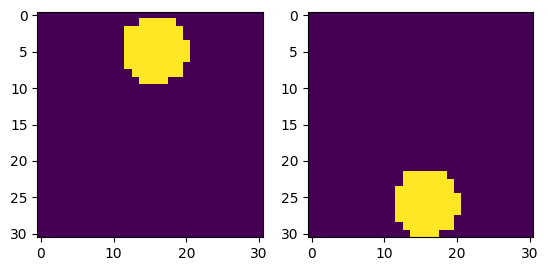

In [289]:
fig, ax = plt.subplots(ncols=2)

for i in range(2):
    ax[i].imshow(img_raw[i])

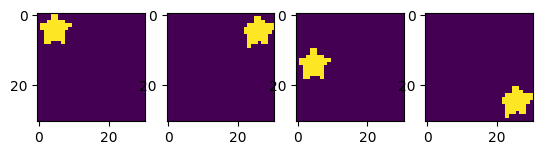

In [290]:
fig, ax = plt.subplots(ncols=4)

for i in range(2):
    ax[i].imshow(intermediate_im_raw[i])

ax[2].imshow(np.roll(intermediate_im_raw[0], axis=0, shift=10))
ax[3].imshow(np.roll(intermediate_im_raw[1], axis=0, shift=20))

In [291]:
num_static = 2
num_trans = 1

frames_transition = 200 
frames_static = 200

frames = {
    'static': frames_static,
    'transition': frames_transition
}

counter = 0

input_stream = []
reward_1_stream = []
reward_2_stream = []

num_phases = 5

num_frames_inter = 2500
num_frames_signal = 750



for phase_id in range(num_phases):
    if phase_id in (0, 2, 4):
        rwd_1 = -0.1
        rwd_2 = -0.1
        num_frames = num_frames_inter
    elif phase_id == 1:
        rwd_1 = 1
        rwd_2 = -0.1
        num_frames = num_frames_signal
    else:
        rwd_1 = -0.1
        rwd_2 = 1
        num_frames = num_frames_signal

    if phase_id == 0:
        frame = intermediate_im_raw[0]
    elif phase_id == 1:
        frame = im_raw[0]
    elif phase_id == 2:
        frame = intermediate_im_raw[1]
    elif phase_id == 3:
        frame = im_raw[1]
    else:
        frame = intermediate_im_raw[0]
        
    
    for i in range(num_frames):
        if phase_id in (0, 2, 4):
            if i % 120 == 0:
                frame = np.roll(frame, axis=0, shift=1)
        
        input_stream.append(frame)
        reward_1_stream.append(rwd_1)
        reward_2_stream.append(rwd_2)


input_stream = np.array(input_stream)
reward_1_stream = np.array(reward_1_stream)
reward_2_stream = np.array(reward_2_stream)

input_stream_gif = input_stream.copy() * 255

input_stream_gif = input_stream_gif.astype(np.uint8)

In [292]:
imageio.mimsave(
        'test.gif',
        input_stream_gif,
        duration=2
    )

In [293]:
np.save("input_stream.npy", input_stream)
np.save("reward_1_stream.npy", reward_1_stream)
np.save("reward_2_stream.npy", reward_2_stream)

In [295]:
input_stream.shape

(9000, 31, 31)

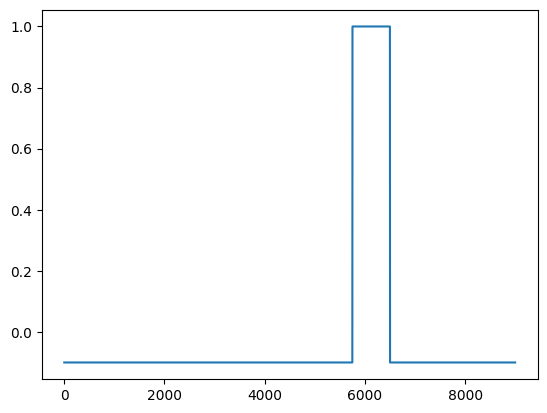

In [296]:
plt.plot(reward_2_stream)

In [297]:
30 * 30

900

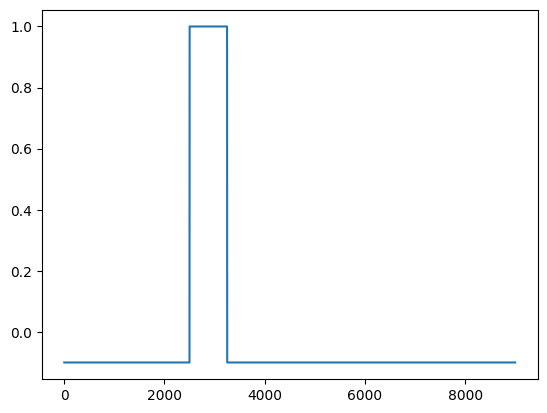

In [298]:
plt.plot(reward_1_stream)